<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_5_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

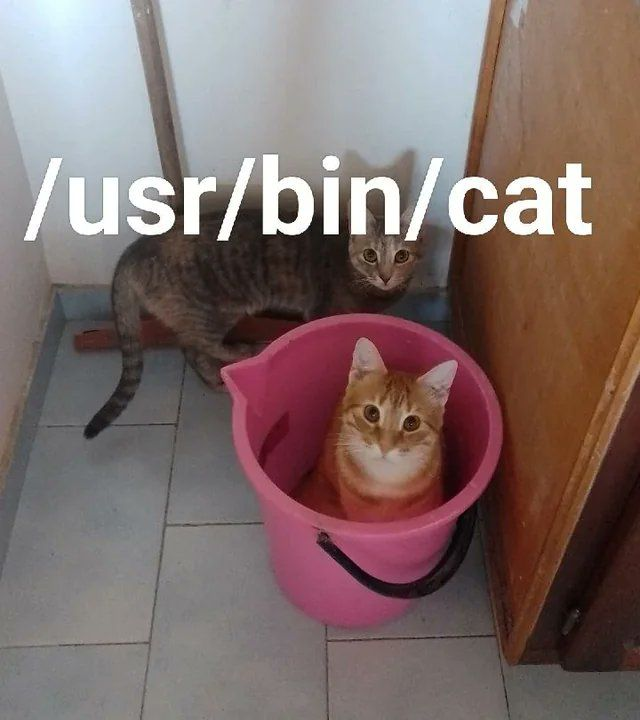

# Разминка
https://pythonist.ru/test-spiski-uroven-srednij/

# Алгоритм Борувки - 2 try

Алгоритм:
1. Изначально каждая вершина — отдельная компонента.

2. Для каждой компоненты:

2.1. найти минимальное ребро, ведущее к другой компоненте.

3. Добавить все найденные рёбра в остов.

4. Объединить соответствующие компоненты.

5. Повторять шаги 2–4, пока не останется одна компонента

https://en.wikipedia.org/wiki/Bor%C5%AFvka%27s_algorithm?utm_source=chatgpt.com

In [ ]:
class DSU:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])  # сжатие пути
        return self.parent[x]

    def union(self, x, y):
        root_x = self.find(x)
        root_y = self.find(y)

        if root_x == root_y:
            return False

        # объединение по рангу
        if self.rank[root_x] < self.rank[root_y]:
            self.parent[root_x] = root_y
        else:
            self.parent[root_y] = root_x
            if self.rank[root_x] == self.rank[root_y]:
                self.rank[root_x] += 1

        return True


def boruvka(n, edges):
    dsu = DSU(n)
    mst_weight = 0
    mst_edges = []
    components = n

    while components > 1:
        cheapest = [-1] * n

        # ищем минимальное исходящее ребро для каждой компоненты
        for i, (u, v, w) in enumerate(edges):
            root_u = dsu.find(u)
            root_v = dsu.find(v)

            if root_u == root_v:
                continue

            if cheapest[root_u] == -1 or edges[cheapest[root_u]][2] > w:
                cheapest[root_u] = i

            if cheapest[root_v] == -1 or edges[cheapest[root_v]][2] > w:
                cheapest[root_v] = i

        # добавляем найденные рёбра
        for i in range(n):
            if cheapest[i] != -1:
                u, v, w = edges[cheapest[i]]
                if dsu.union(u, v):
                    mst_weight += w
                    mst_edges.append((u, v, w))
                    components -= 1

    return mst_weight, mst_edges

In [ ]:
edges = [
    (0, 1, 4),
    (0, 2, 3),
    (1, 2, 1),
    (1, 3, 2),
    (2, 3, 5)
]

weight, mst = boruvka(4, edges)

print("Вес MST:", weight)
print("Рёбра MST:", mst)

Вес MST: 6
Рёбра MST: [(0, 2, 3), (1, 2, 1), (1, 3, 2)]


# Паросочетания - см. семинар 2_4_25_26

# Потоки

**Задача.** Есть дом, вода из которого стекает в реку по водопроводу. Водопровод — это набор однонаправленных труб, концы которых соединены с домом, рекой или одним из $n$ соединительных узлов. Также для каждой трубы известна ее прочность — сколько воды она может выдержать. Необходимо найти максимальный объем воды, который может вытекать из дома в единицу времени.

Поставим задачу более формально. Есть граф в котором выделены две вершины, соответствующие дому $s$ и реке $t$, а остальные вершины соответствуют узлам. Ребра этого графа соответствуют трубам водопровода, и у каждого ребра есть пропускная способность — максимальное количество воды, которое может по нему течь. Обозначим за $c(v,u)$ пропускную способность ребра из $v$ в $u$, а $f(v,u)$ — количество воды, текущее по нему.

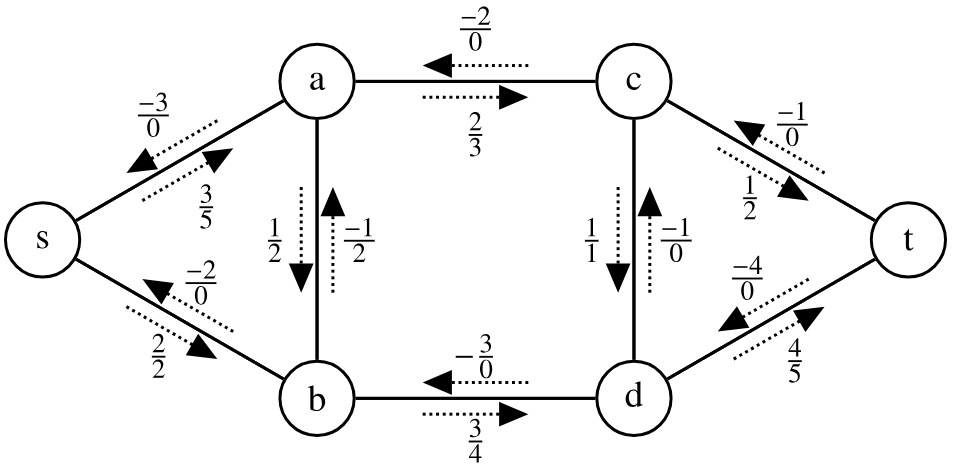

Заметим некоторые свойства воды, текущей в водопроводе. Например, для любой вершины, которая соответствует узлу, объем втекающей в неё воды равен объему вытекающей из неё воды:
$∑_u f(u,v)= ∑_u f(v,u)$
Это значит, что вода не может появится из ниоткуда и исчезнуть в никуда.

Также удобно считать, что у любого ребра есть ровно одно обратное, и $f(v,u)=−f(u,v)$, то есть если по ребру из $v$ в
$u$ перетекает $x$ потока, то по ребру из $u$ в $v$ перетекает
$−x$ потока.

Теперь замечание о втекающем и вытекающем объеме звучит так, что для любой вершины $v$, кроме истока $s$ и стока $t$: $∑_u f(v,u)=0$

Наша задача тогда — это найти такую функцию $f$, максимизирующую
$∑f(s,u)=∑f(u,t)$, удовлетворяющую предыдущим равенствам, и при этом не превышающая ни одну пропускную способность: $f(v,u)≤c(v,u)$

# Поток минимальной стоимости

Рассмотрим ориентированный граф $G=(V,E)$ с истоком $s$ и стоком $t$, в котором у каждого ребра $(u,v)$ задана целая стоимость $w_{uv}$  и целая положительная пропускная способность $c_{uv}$. Требуется найти максимальный поток, стоимость которого минимальна:

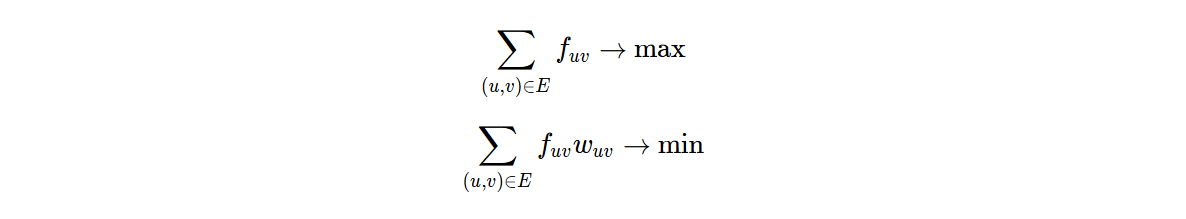

Заметим, что рёбра отрицательной стоимости по условию возможны. Мы дополнительно предполагаем, что циклов отрицательного веса нет.

Модифицируем сеть, добавив стандартным образом обратные рёбра, позволяющие «отменять» операции: для каждого ребра $(u,v)$ добавим $(v,u)$, для которого $c_{vu} = 0$ и $w_{vu} = −w_{uv}$. Напомним, что остаточной сетью называется граф из рёбер, остаточная пропускная способность которых ненулевая ($c_{uv} −f_{uv}>0 $).

## Критерий оптимальности
**Утверждение**. Если в остаточной сети нет циклов отрицательного веса, то поток оптимален (и наоборот).

**Доказательство**:  
→ Рассмотрим произвольный неоптимальный поток $f$ и оптимальный поток $f^∗$. Рассмотрим разность $f^∗−f$. Она является циркуляцией, а любая циркуляция может быть разложена на сумму простых циклов. Хотя бы один из этих циклов будет иметь отрицательную стоимость, так как стоимость $f^∗$ меньше стоимости $f$, что противоречит предположению.

← Пусть цикл существует, тогда мы можем пропустить поток по этому циклу и получить поток меньшей стоимости.

Этот критерий сразу даёт нам относительно простой алгоритм: найдем какой-нибудь максимальный поток и будем «отменять» циклы отрицательного веса в остаточной цепи, пока такие циклы существуют. Искать цикл нам придётся не более $mUC$ раз где
$U$ — величина потока,
$C$ — максимальная пропускная способность ребра. Этой величиной ограничен модуль минимальной стоимости ответа, а каждый отмененный цикл уменьшает ответ хотя бы на единицу.

Если искать цикл алгоритмом Форда-Беллмана, то асимптотика алгоритма составит $O(m^2nUC)$ (предполагая, что какой-нибудь максимальный поток мы уже нашли).

Ещё одно определение:
**Дополнительный поток** (чаще говорят увеличивающий поток или augmenting flow) — это количество потока, которое можно дополнительно пропустить по найденному увеличивающему пути в остаточной сети.

Это сколько ещё потока можно “добавить” по выбранному пути от источника к стоку.

## Алгоритм Форда–Фалкерсона

Алгоритм Форда–Фалкерсона — классический метод решения задачи максимального потока в сети. Он был предложен математиками Лестером Рэндольфом Фордом-младшим и Делбертом Рэем Фалкерсоном в 1956 году.

**Главная идея алгоритма**:

Пока существует путь из источника $s$ в сток $t$, по которому можно пропустить дополнительный поток — увеличиваем поток вдоль этого пути.

Представьте систему труб:

* каждая труба имеет максимальную пропускную способность

* вода идёт от источника к стоку

Мы пытаемся протолкнуть как можно больше воды.

Алгоритм делает это постепенно:

* находит путь

* отправляет по нему максимально возможный поток

* обновляет сеть

* повторяет

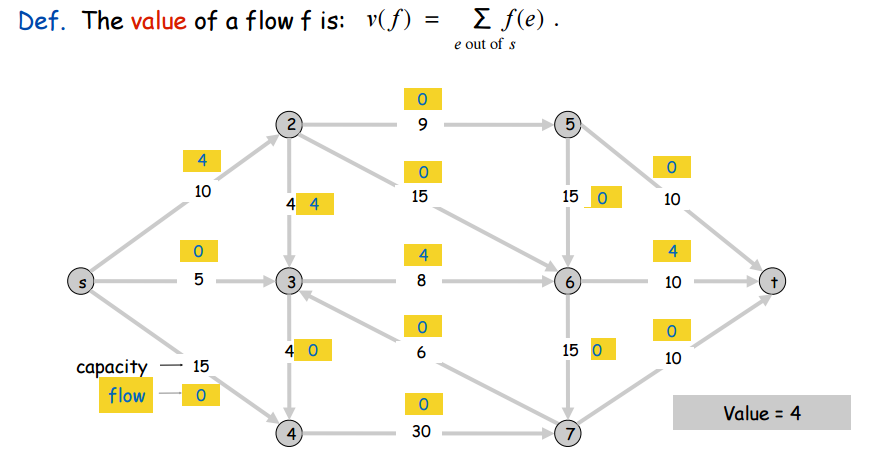

Ключевая идея алгоритма — **остаточная сеть**.

Для каждого ребра создаются:

* прямое ребро

* обратное ребро

Если по ребру уже течёт поток, его можно частично отменить, используя обратное ребро.

**Остаточная пропускная способность**

$c_f(u,v)=c(u,v)−f(u,v)$

сколько ещё можно пропустить через ребро.

In [ ]:
from collections import defaultdict

def dfs(graph, s, t, visited, flow):
    if s == t:
        return flow

    visited.add(s)

    for v in graph[s]:
        capacity = graph[s][v]
        if v not in visited and capacity > 0:
            pushed = dfs(graph, v, t, visited, min(flow, capacity))
            if pushed > 0:
                graph[s][v] -= pushed
                graph[v][s] += pushed
                return pushed

    return 0


def ford_fulkerson(graph, source, sink):
    max_flow = 0

    while True:
        visited = set()
        pushed = dfs(graph, source, sink, visited, float('inf'))

        if pushed == 0:
            break

        max_flow += pushed

    return max_flow

Посмотрим на ключевой участок:
```python
graph[s][v] -= pushed
graph[v][s] += pushed
```
Здесь:
```python
graph[s][v] — уменьшаем остаточную пропускную способность

graph[v][s] — увеличиваем пропускную способность обратного ребра
```
Если обратного ребра раньше не было, defaultdict создаёт его автоматически:
```python
graph[v][s] = 0
```
и затем увеличивает.

### Более полная реализация
```
graph[u][v] = остаточная пропускная способность
```

In [ ]:
from collections import defaultdict

class Graph:
    def __init__(self):
        # остаточный граф
        self.graph = defaultdict(lambda: defaultdict(int))

    def add_edge(self, u, v, capacity):
        # добавляем прямое ребро
        self.graph[u][v] += capacity

        # создаём обратное ребро (если его ещё нет)
        self.graph[v][u] += 0

    def dfs(self, u, t, visited, flow):
        # если дошли до стока — возвращаем поток
        if u == t:
            return flow

        visited.add(u)

        # перебираем соседей
        for v in self.graph[u]:
            capacity = self.graph[u][v]

            # если не посещали и есть остаточная пропускная способность
            if v not in visited and capacity > 0:

                pushed = self.dfs(v, t, visited, min(flow, capacity))

                if pushed > 0:
                    # уменьшаем прямое ребро
                    self.graph[u][v] -= pushed

                    # увеличиваем обратное
                    self.graph[v][u] += pushed

                    return pushed

        return 0

    def ford_fulkerson(self, s, t):
        max_flow = 0

        while True:
            visited = set()

            pushed = self.dfs(s, t, visited, float('inf'))

            if pushed == 0:
                break

            max_flow += pushed

        return max_flow

In [ ]:
g = Graph()

g.add_edge(0, 1, 10)
g.add_edge(0, 2, 5)
g.add_edge(1, 2, 15)
g.add_edge(1, 3, 10)
g.add_edge(2, 3, 10)

print(g.ford_fulkerson(0, 3))

15


Разберём пример, где алгоритм сначала выбирает неудачный путь, а потом исправляет его с помощью обратных рёбер.

```
s → A (10)
s → B (10)
A → B (2)
A → t (8)
B → t (10)
```
Допустим DFS нашёл путь:
```
s → A → B → t
```
Пропускные способности:
```
s → A = 10
A → B = 2
B → t = 10
```
Минимум:
```
min(10,2,10) = 2
```
Добавляем поток 2.

Поток после шага
```
s → A : 2
A → B : 2
B → t : 2
```
Остаточные capacity:
```
s → A : 8
A → B : 0
B → t : 8
```
И появляются обратные рёбра:
```
A ← B : 2
A ← s : 2
t ← B : 2
```

Теперь алгоритм найдёт путь:
```
s → A → t
```
Пропускные способности:
```
s → A = 8
A → t = 8
```
Минимум:
```
8
```
Добавляем поток 8.

Поток теперь
```
s → A = 10
A → B = 2
A → t = 8
B → t = 2
```

Третий путь

Следующий путь:
```
s → B → t
```
Минимум:
```
10
```
Но B → t уже содержит поток 2, поэтому остаточная capacity:
```
B → t = 8
```
Добавляем 8.

Итоговый поток
```
s → A = 10
s → B = 8
A → B = 2
A → t = 8
B → t = 10
```
Общий поток:
```
18
```

### Сложность

Зависит от того, как ищется путь.

В общем виде: $O(E⋅∣f∣)$

где:
$E$ — число рёбер  
$∣f∣$ — значение максимального потока

## Алгоритм Эдмондса–Карпа

Это улучшенная версия Алгоритма Форда–Фалкерсона.
Он был предложен учёными Джеком Эдмондсом и Ричардом Карпом.

**Главное отличие:**

увеличивающий путь ищется по кратчайшему числу рёбер с помощью BFS.


**Идея:**

1️⃣ строим остаточную сеть  
2️⃣ ищем кратчайший путь (по числу рёбер) из $s$ в $t$  
3️⃣ увеличиваем поток на этом пути  
4️⃣ обновляем остаточную сеть  
5️⃣ повторяем

Итак,

1️⃣ Инициализация

Все потоки равны: $f(u,v)=0$

2️⃣ Построение остаточной сети

Для каждого ребра:
$c_f (u,v)=c(u,v)−f(u,v)$

3️⃣ Поиск увеличивающего пути

Используем BFS, чтобы найти путь: $s→t$,

где $c_f (u,v)>0$

4️⃣ Определение дополнительного потока:
$Δ = min (c_f(u,v))$

минимальная пропускная способность на пути.

5️⃣ Обновление потоков

Для каждого ребра пути:

* увеличиваем прямое ребро

* уменьшаем обратное

6️⃣ Повтор

Алгоритм работает, пока существует путь $s→t$.

**Сложность**

Алгоритм Эдмондса–Карпа имеет гарантированную сложность:
$O(VE^2)$
где:
$V$ — число вершин
$E$ — число рёбер

**Причина**:

* каждый BFS стоит $O(E)$

* число увеличивающих путей $≤ O(VE)$

In [ ]:
from collections import deque

def bfs(graph, s, t, parent):
    visited = set()
    queue = deque([s])
    visited.add(s)

    while queue:
        u = queue.popleft()

        for v in graph[u]:
            if v not in visited and graph[u][v] > 0:
                parent[v] = u
                visited.add(v)

                if v == t:
                    return True

                queue.append(v)

    return False


def edmonds_karp(graph, s, t):
    parent = {}
    max_flow = 0

    while bfs(graph, s, t, parent):

        flow = float('inf')
        v = t

        while v != s:
            u = parent[v]
            flow = min(flow, graph[u][v])
            v = u

        v = t
        while v != s:
            u = parent[v]

            graph[u][v] -= flow
            graph[v][u] += flow

            v = u

        max_flow += flow

    return max_flow

In [ ]:
from collections import defaultdict, deque

# создание графа
graph = defaultdict(lambda: defaultdict(int))

# добавление рёбер
graph['s']['A'] = 10
graph['s']['B'] = 5
graph['A']['B'] = 15
graph['A']['t'] = 10
graph['B']['t'] = 10

# обязательно создаём обратные рёбра
for u in list(graph):
    for v in list(graph[u]):
        if u not in graph[v]:
            graph[v][u] = 0

In [ ]:
max_flow = edmonds_karp(graph, 's', 't')
print("Max flow:", max_flow)

Max flow: 0
